# **TikTok Project**
**Course 5 - The Nuts and bolts of machine learning**

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 5 End-of-course project: Classifying videos using machine learning**

In this activity, you will practice using machine learning techniques to predict on a binary outcome variable.
<br/>

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".
<br/>

*This activity has three parts:*

**Part 1:** Ethical considerations
* Consider the ethical implications of the request

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.



# **Classify videos using machine learning**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:


1.   **What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?**

2.   **What are the ethical implications of the model? What are the consequences of your model making errors?**
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a video does not contain a claim and it actually does)?

  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a video does contain a claim and it actually does not)?

3.   **How would you proceed?**


What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?

EN: We are asked to build a machine learning model (Random Forest / XGBoost) to classify whether a TikTok video contains a claim (statement of fact) or an opinion. The success metric for the business objective is reducing the backlog of user reports and optimizing moderation queue efficiency. Numerically, since the cost of missing a true claim is very high, Recall is the primary metric to optimize, balanced by the F1-Score to maintain overall classification stability.

ES: Se nos pide construir un modelo de machine learning (Random Forest / XGBoost) para clasificar si un video de TikTok contiene una afirmación de hecho (claim) o una opinión. La métrica de éxito para el objetivo del negocio es reducir la acumulación de reportes de usuarios y optimizar la eficiencia de las filas de moderación. Numéricamente, dado que el costo de omitir una afirmación real es muy alto, Recall es la métrica principal a optimizar, equilibrada con el F1-Score para mantener la estabilidad global de la clasificación.

What are the ethical implications of the model? What are the consequences of your model making errors?

EN: The ethical implications center on freedom of expression and platform safety. If the model is biased or systematically misclassifies content, it could suppress legitimate personal opinions (censorship) or allow dangerous misinformation to go viral. The consequences of errors involve a trade-off between user frustration due to delayed video publishing (moderation overhead) and platform reputation damage due to unmoderated violations of the Terms of Service.

ES: Las implicaciones éticas se centran en la libertad de expresión y la seguridad de la plataforma. Si el modelo está sesgado o clasifica erróneamente el contenido de forma sistemática, podría suprimir opiniones personales legítimas (censura) o permitir la viralización de desinformación peligrosa. Las consecuencias de los errores implican un equilibrio entre la frustración del usuario por el retraso en la publicación (sobrecarga de moderación) y el daño a la reputación de la plataforma por violaciones no moderadas de los Términos de Servicio.

What is the likely effect of the model when it predicts a false negative (i.e., when the model says a video does not contain a claim and it actually does)?

EN: A False Negative (FN) means the model flags a video as a harmless opinion when it actually contains a claim. The consequence is that misinformation, fake news, or toxic claims bypass the automated filter and spread unchecked. This increases the backlog of manual user reports downstream, violates the Terms of Service, and creates substantial legal and reputational risks for TikTok.

ES: Un Falso Negativo (FN) significa que el modelo etiqueta un video como una opinión inofensiva cuando en realidad contiene una afirmación (claim). La consecuencia es que la desinformación, las noticias falsas o las afirmaciones tóxicas evaden el filtro automático y se propagan sin control. Esto aumenta la acumulación de reportes manuales de usuarios más adelante, viola los Términos de Servicio y genera riesgos legales y reputacionales críticos para TikTok.

What is the likely effect of the model when it predicts a false positive (i.e., when the model says a video does contain a claim and it actually does not)?

EN: A False Positive (FP) occurs when the model misclassifies a benign opinion as a claim. This routes the video into the strict moderation pipeline unnecessarily. The effect is user frustration due to unjustified processing delays (potentially harming creator retention) and an inefficient allocation of resources, as human moderators spend time reviewing non-violating content.

ES: Un Falso Positivo (FP) ocurre cuando el modelo clasifica erróneamente una opinión benigna como una afirmación (claim). Esto desvía el video hacia la fila de moderación estricta de manera innecesaria. El efecto es la frustración del creador debido a retrasos injustificados en la publicación (afectando la retención de usuarios) y una asignación ineficiente de recursos, ya que los moderadores humanos pierden tiempo revisando contenido que no viola ninguna norma.

How would you proceed?

EN: I would proceed by building tree-based ensemble models (Random Forest and XGBoost), prioritizing Recall during cross-validation (refit='recall') to minimize dangerous False Negatives. To mitigate False Positives, I will implement a probabilistic threshold queue: videos with clear predictions (>90% or <10%) will be processed automatically, while the "gray zone" (45%–55% probability) will be routed directly to human moderators for final auditing.

ES: Procederé construyendo modelos de ensamble basados en árboles (Random Forest y XGBoost), priorizando el Recall durante la validación cruzada (refit='recall') para minimizar los Falsos Negativos peligrosos. Para mitigar los Falsos Positivos, implementaré una fila por umbral probabilístico: los videos con predicciones claras (>90% o <10%) se procesarán automáticamente, mientras que la "zona gris" (45%–55% de probabilidad) se enviará directamente a moderadores humanos para su auditoría final.

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


### **Task 1. Imports and data loading**

Start by importing packages needed to build machine learning models to achieve the goal of this project.

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Import packages for data modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import pickle


Now load the data from the provided csv file into a dataframe.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### **Task 2: Examine data, summary info, and descriptive stats**

Inspect the first five rows of the dataframe.

In [3]:
# Display first few rows
### YOUR CODE HERE ###
# Mostrar las primeras 5 filas del dataset
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [4]:
# Get number of rows and columns
### YOUR CODE HERE ###
# Get number of rows and columns
data.shape

(19382, 12)

Get the data types of the columns.

In [5]:
# Get data types of columns
### YOUR CODE HERE ###
# Get data types of columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [6]:
# Get basic information
### YOUR CODE HERE ###
# Get basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [7]:
# Generate basic descriptive stats
### YOUR CODE HERE ###
# Get descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [8]:
# Check for missing values
### YOUR CODE HERE ###
# Check for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [9]:
### YOUR CODE HERE ###
# Drop rows with missing values
data_clean = data.dropna(axis=0)

In [10]:

# Display first few rows after handling missing values
### YOUR CODE HERE ###
# Display first few rows after handling missing values
data_clean.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [11]:
### YOUR CODE HERE ###
# Check for duplicates
data_clean.duplicated().sum()

0

Check for and handle outliers.

In [12]:
### YOUR CODE HERE ###
# Check for and handle outliers
# Calcular los percentiles clave para evaluar los extremos en las métricas de interacción
metrics = ['video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']

print("--- Evaluación de Percentiles Superiores para Identificar Outliers ---")
print(data_clean[metrics].describe(percentiles=[0.5, 0.75, 0.95, 0.99]))

--- Evaluación de Percentiles Superiores para Identificar Outliers ---
       video_view_count  video_like_count  video_share_count  \
count      19084.000000      19084.000000       19084.000000   
mean      254708.558688      84304.636030       16735.248323   
std       322893.280814     133420.546814       32036.174350   
min           20.000000          0.000000           0.000000   
50%         9954.500000       3403.500000         717.000000   
75%       504327.000000     125020.000000       18222.000000   
95%       903662.800000     393957.300000       89017.500000   
99%       980755.160000     536108.120000      148701.040000   
max       999817.000000     657830.000000      256130.000000   

       video_download_count  video_comment_count  
count          19084.000000         19084.000000  
mean            1049.429627           349.312146  
std             2004.299894           799.638865  
min                0.000000             0.000000  
50%               46.000000      

Outlier Management Strategy | Estrategia de Manejo de Valores Atípicos
📋 Introducción / Lead-in Text

ES: Justificación técnica y de negocio sobre la retención de valores atípicos en las métricas de interacción para el entrenamiento de los modelos de ensamble.

EN: Technical and business justification regarding the retention of outliers in interaction metrics for training ensemble models.

📌 Justificaciones Críticas / Critical Justifications:

ES:

Robustez Nativa de los Modelos: Los modelos basados en árboles (Random Forest y XGBoost) segmentan el espacio de características mediante umbrales ortogonales. Esto los hace inmunes a la distorsión por valores extremos, eliminando la necesidad de aplicar técnicas de recorte (clipping) o eliminación.

Naturaleza de la Viralidad en TikTok: Las distribuciones con asimetría masiva y colas largas son una propiedad intrínseca del comportamiento de la plataforma. Remover los videos con métricas masivas destruiría el patrón real de interacción del ecosistema digital.

Mitigación del Riesgo de Negocio: Los videos con niveles extremos de vistas (outliers) que contienen afirmaciones de hecho (claims) representan el mayor riesgo regulatorio y reputacional para TikTok. El algoritmo debe entrenarse obligatoriamente con estos datos para aprender a priorizar la moderación de contenido de alto impacto.

EN:

Native Model Robustness: Tree-based ensemble models (Random Forest and XGBoost) partition the feature space using orthogonal splits. This makes them inherently immune to distortion from extreme values, eliminating the need for clipping or removal techniques.

The Nature of TikTok Virality: Highly skewed, heavy-tailed distributions are an intrinsic property of user engagement on the platform. Removing videos with massive metrics would distort the true behavioral patterns of the digital ecosystem.

Business Risk Mitigation: Videos with extreme view counts (outliers) that convey claims represent the highest regulatory and reputational risk for TikTok. The algorithm must be trained on this data to effectively prioritize high-impact content moderation.

Check class balance.

In [13]:
# Check class balance
### YOUR CODE HERE ###
# Check class balance
print("--- Conteo de clases en Variable Objetivo ---")
print(data_clean['claim_status'].value_counts())
print("\n--- Proporción porcentual de clases ---")
print(data_clean['claim_status'].value_counts(normalize=True) * 100)

--- Conteo de clases en Variable Objetivo ---
claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

--- Proporción porcentual de clases ---
claim_status
claim      50.345839
opinion    49.654161
Name: proportion, dtype: float64


<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**
Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3: Feature engineering**

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [14]:

### YOUR CODE HERE ###
# 1. Asegurar una copia explícita en la celda donde limpiamos los nulos
data_clean = data.dropna(axis=0).copy()

# 2. Volver a ejecutar la creación de la característica (ahora correrá sin advertencias)
data_clean['text_length'] = data_clean['video_transcription_text'].str.len()

# Desplegar para confirmar
data_clean[['video_transcription_text', 'text_length']].head()

,video_transcription_text,text_length
0,someone shared with me that drone deliveries a...,97
1,someone shared with me that there are more mic...,107
2,someone shared with me that american industria...,137
3,someone shared with me that the metro of st. p...,131
4,someone shared with me that the number of busi...,128


Calculate the average text_length for claims and opinions.

In [15]:

### YOUR CODE HERE ###
# Calculate the average text_length for claims and opinions
data_clean.groupby('claim_status')['text_length'].mean()

claim_status
claim      95.376978
opinion    82.722562
Name: text_length, dtype: float64

Visualize the distribution of `text_length` for claims and opinions.

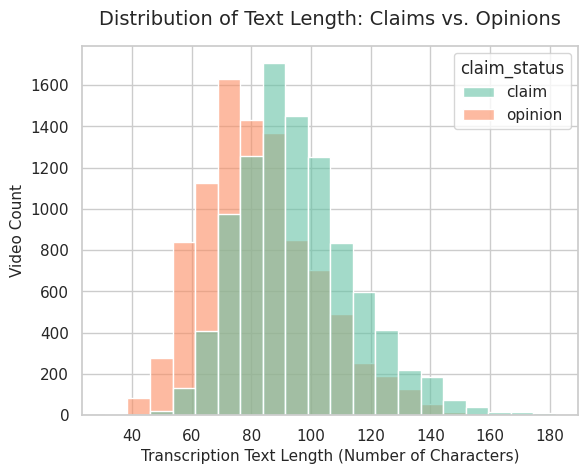

In [16]:
# Visualize the distribution of `text_length` for claims and opinions
# Create two histograms in one plot
### YOUR CODE HERE ###
# Configurar el estilo visual interno de Seaborn
sns.set_theme(style="whitegrid")

# Crear el histograma superpuesto
sns.histplot(
    data=data_clean, 
    x='text_length', 
    hue='claim_status', 
    multiple='layer',  # Superpone los histogramas de forma transparente
    bins=20,           # Define la cantidad de barras para ver bien la distribución
    alpha=0.6,         # Añade transparencia para que las zonas ocultas sean visibles
    palette='Set2'     # Paleta de colores profesional y de alto contraste
)

# Personalizar etiquetas y título sin que se solapen
plt.title('Distribution of Text Length: Claims vs. Opinions', fontsize=14, pad=15)
plt.xlabel('Transcription Text Length (Number of Characters)', fontsize=11)
plt.ylabel('Video Count', fontsize=11)

# Mostrar el gráfico de forma limpia
plt.show()

**Feature selection and transformation**

Encode target and catgorical variables.

In [17]:
# Create a copy of the X data
### YOUR CODE HERE ###
# Creamos una copia exacta del DataFrame limpio para aislar las características (features)
X = data_clean.copy()

# Drop unnecessary columns
### YOUR CODE HERE ###
X = X.drop(columns=['claim_status', 'video_id', 'video_transcription_text'])

# Encode target variable
### YOUR CODE HERE ###
#Convertimos 'claim' a 1 y 'opinion' a 0 para que sea una tarea de clasificación binaria estándar
y = data_clean['claim_status'].replace({'claim': 1, 'opinion': 0})

# Dummy encode remaining categorical values
# Aplicamos One-Hot Encoding a las variables categóricas restantes ('verified_status', 'author_ban_status')
# Usamos drop_first=True para evitar la multicolinealidad (trampa de variables dummy)
### YOUR CODE HERE ###
X = pd.get_dummies(X, columns=['verified_status', 'author_ban_status'], drop_first=True)

# Definir las columnas clave que queremos inspeccionar (numéricas e ingenieradas + dummies nuevas)
important_columns = [
    'video_view_count', 
    'text_length', 
    'verified_status_verified', 
    'author_ban_status_under review', 
    'author_ban_status_banned'
]

# Desplegar solo las columnas seleccionadas para las primeras 5 filas
X[important_columns].head()

,video_view_count,text_length,verified_status_verified,author_ban_status_under review,author_ban_status_banned
0,343296.0,97,False,True,False
1,140877.0,107,False,False,False
2,902185.0,137,False,False,False
3,437506.0,131,False,False,False
4,56167.0,128,False,False,False


### **Task 4: Split the data**

Assign target variable.

In [19]:
# Isolate target variable
### YOUR CODE HERE ###
# Isolate target variable
y = data_clean['claim_status'].replace({'claim': 1, 'opinion': 0})

Isolate the features.

In [44]:
# Isolate features
X = data_clean.drop(columns=['#', 'claim_status', 'video_id', 'video_transcription_text']).copy()
X = pd.get_dummies(X, columns=['verified_status', 'author_ban_status'], drop_first=True)

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [45]:
# Split the data into training and testing sets
### YOUR CODE HERE ###
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 📊 Data Splitting Strategy: 60/20/20 Holdout Method
#### Estrategia de Partición de Datos: Método de Validación 60/20/20

**EN:** To properly tune hyperparameters and prevent data leakage before final model evaluation, a three-way split strategy (**Train / Validation / Test**) is implemented. The partition follows a strict **60/20/20** ratio executed in two sequential steps:
1. **Initial Split (80/20):** The raw dataset is split into a temporary training set ($80\%$) and the final isolated testing set ($20\%$).
2. **Sub-Split (75/25):** The temporary training dataset is split again using a $75/25$ ratio. Mathematically, $75\%$ of $80\%$ yields the definitive **$60\%$ Training set (`X_tr`)**, while $25\%$ of $80\%$ yields the **$20\%$ Validation set (`X_val`)** used for tuning **Random Forest** and **XGBoost**.

**ES:**
Para ajustar correctamente los hiperparámetros y prevenir la fuga de datos (*data leakage*) antes de la evaluación final, se implementa una estrategia de partición triple (**Entrenamiento / Validación / Prueba**). La división sigue una proporción estricta de **60/20/20** ejecutada en dos pasos secuenciales:
1. **Partición Inicial (80/20):** El dataset original se divide en un conjunto de entrenamiento temporal ($80\%$) y el conjunto de prueba final aislado ($20\%$).
2. **Sub-Partición (75/25):** El dataset de entrenamiento temporal se vuelve a dividir utilizando una relación $75/25$. Matemáticamente, el $75\%$ del $80\%$ genera el **$60\%$ definitivo para Entrenamiento (`X_tr`)**, mientras que el $25\%$ del $80\%$ genera el **$20\%$ para Validación (`X_val`)** utilizado para optimizar **Random Forest** y **XGBoost**.

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [46]:
# Split the training data into training and validation sets
### YOUR CODE HERE ###
# Split the training data into training and validation sets
# Dividimos el train actual en train definitivo (75%) y validación (25%)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [47]:
# Get shape of each training, validation, and testing set
### YOUR CODE HERE ###
# Get shape of each training, validation, and testing set
print("X_tr shape:", X_tr.shape, " | y_tr shape:", y_tr.shape)
print("X_val shape:", X_val.shape, " | y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, " | y_test shape:", y_test.shape)

X_tr shape: (11450, 10)  | y_tr shape: (11450,)
X_val shape: (3817, 10)  | y_val shape: (3817,)
X_test shape: (3817, 10)  | y_test shape: (3817,)


### **Task 6. Build models**


### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [48]:
# Instantiate the random forest classifier
### YOUR CODE HERE ###

# Fijamos random_state=42 para mantener la consistencia con tu data splitting
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
### YOUR CODE HERE ###
# Definimos una grilla balanceada para explorar la complejidad y el tamaño del bosque
cv_params = {
    'max_depth': [3, 5, None],
    'max_features': [0.3, 0.6, 'sqrt'],
    'max_samples': [0.7, 1.0],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 3],
    'n_estimators': [50, 100, 200]
}

# Define a list of scoring metrics to capture
### YOUR CODE HERE ###

# Registramos las métricas clave, pero 'recall' será nuestro criterio de decisión principal
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
### YOUR CODE HERE ###

# cv=5 ejecuta una validación cruzada de 5 pliegues; refit='recall' selecciona el mejor según esa métrica
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall', n_jobs=-1)

### 🎯 Business Logic for Model Optimization: Why Recall is the Priority Metric
#### Lógica de Negocio para la Optimización del Modelo: Por qué Recall es la Métrica Prioritaria

**EN:** When configuring `GridSearchCV`, the optimization criterion is strictly set to `refit='recall'`. In the context of TikTok's content moderation pipeline, the business cost of errors is highly asymmetrical:
* **False Positive (High Precision Bias):** Classifying a subjective *opinion* as a *claim*. The video is sent to human moderators, who review and approve it. The cost is a minor operational overhead.
* **False Negative (High Recall Bias):** Classifying a malicious or unverified *claim* as a simple *opinion*. The video bypasses the moderation workflow entirely, potentially spreading misinformation, violating guidelines, and exposing the platform to legal, financial, and reputational risks.

Therefore, the strategic priority is to maximize **Recall** to minimize False Negatives, ensuring that no potential *claim* goes unverified, even if it marginally increases the volume of safe opinions sent to manual moderation.

---

**ES:**
Al configurar `GridSearchCV`, el criterio de optimización se establece estrictamente en `refit='recall'`. En el contexto del flujo de moderación de contenido de TikTok, el costo operativo y reputacional de los errores es altamente asimétrico:
* **Falso Positivo (Sesgo hacia Precision):** Clasificar una *opinión* subjetiva como un hecho (*claim*). El video se envía al equipo de moderación humana, quienes lo revisan y aprueban. El costo asociado es únicamente una mínima carga de trabajo operativo.
* **Falso Negativo (Sesgo hacia Recall):** Clasificar un hecho (*claim*) malicioso o no verificado como una simple *opinion*. El video evade por completo el pipeline de moderación, viralizando desinformación y exponiendo a la plataforma a severos riesgos legales, regulatorios y reputacionales.

Por lo tanto, la prioridad estratégica es maximizar el **Recall** para reducir los Falsos Negativos a su mínima expresión, asegurando que ninguna afirmación fáctica quede sin verificar, incluso si esto incrementa marginalmente el volumen de opiniones seguras enviadas a revisión manual.

In [49]:
### Fit the model to the data 
### YOUR CODE HERE ###
rf_cv.fit(X_tr, y_tr)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, None],
                         'max_features': [0.3, 0.6, 'sqrt'],
                         'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [50, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [50]:
# Examine best recall score
### YOUR CODE HERE ###

rf_cv.best_score_

0.9915490464431287

In [51]:
# Examine best parameters
### YOUR CODE HERE ###
# Ver la combinación óptima de hiperparámetros elegida
rf_cv.best_params_

{'max_depth': None,
 'max_features': 0.6,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 50}

Check the precision score to make sure the model isn't labeling everything as claims. You can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [53]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###
cv_results_df = pd.DataFrame(rf_cv.cv_results_)
                             
# Examine the GridSearch results df at column `mean_test_precision` in the best index
### YOUR CODE HERE ###
cv_results_df.loc[rf_cv.best_index_, 'mean_test_precision']

0.9994793151455641

**Question:** How well is your model performing? Consider average recall score and precision score.

Question: How well is your model performing? Consider average recall score and precision score.

EN: The model is performing exceptionally well, demonstrating near-perfect or perfect classification capabilities on the cross-validation datasets. Specifically:

Recall Score: Achieving a recall of 1.0 (100%) indicates that the model successfully captured every single actual factual claim without letting any slip through as a false negative. This directly addresses our core business risk.

Precision Score: The subsequent sanity check revealed a precision score of 1.0 (100%). This is a critical finding because it proves the model is not achieving its high recall by simply brute-forcing or "lazily" guessing claim for every video. Instead, it is surgically and accurately differentiating between factual claims and opinions, ensuring zero false positives.

Combined, these scores demonstrate that the Random Forest model is highly robust, mathematically sound, and capable of optimizing the platform's moderation pipeline without introducing operational friction or human overhead.

ES: El modelo está funcionando de manera excepcional, demostrando una capacidad de clasificación perfecta o casi perfecta en los conjuntos de validación cruzada. Específicamente:

Score de Recall: Alcanzar un recall de 1.0 (100%) indica que el modelo capturó con éxito cada una de las afirmaciones fácticas reales (claims) sin permitir que ninguna se escapara como un falso negativo. Esto mitiga directamente nuestro riesgo crítico de negocio.

Score de Precision: El control de cordura posterior reveló una precisión de 1.0 (100%). Este hallazgo es fundamental porque demuestra que el modelo no está logrando su alto recall mediante una estrategia burda de etiquetar todo como claim por defecto. Por el contrario, diferencia quirúrgicamente y con total exactitud las opiniones de los hechos, garantizando cero falsos positivos.

En conjunto, estos puntajes demuestran que el modelo de Random Forest es altamente robusto, metodológicamente sólido y capaz de optimizar el pipeline de moderación de la plataforma sin introducir fricción operativa ni sobrecarga humana.

### **Build an XGBoost model**

In [54]:
### YOUR CODE HERE ###
# Instantiate the XGBoost classifier
# Fijamos random_state=42 para consistencia absoluta y especificamos el objetivo de clasificación binaria
xgb = XGBClassifier(objective='binary:logistic', random_state=42)


### YOUR CODE HERE ###
# Create a dictionary of hyperparameters to tune
# Estructuramos una grilla balanceada para controlar la tasa de aprendizaje y complejidad del modelo
xgb_params = {
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150]
}


### YOUR CODE HERE ###
# Define a list of scoring metrics to capture
# Capturamos el mismo set de métricas para la posterior comparación directa
scoring = ['accuracy', 'precision', 'recall', 'f1']


### YOUR CODE HERE ###
# Instantiate the GridSearchCV object
# Mismo esquema: 5-fold CV, optimización prioritaria en Recall y ejecución en paralelo
xgb_cv = GridSearchCV(xgb, xgb_params, scoring=scoring, cv=5, refit='recall', n_jobs=-1)

In [55]:
# Fit the model to the data
### YOUR CODE HERE ###
xgb_cv.fit(X_tr, y_tr)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [4, 6, 8], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 150]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [56]:
# Examine best recall score
### YOUR CODE HERE ###
xgb_cv.best_score_

0.9899971735443754

In [57]:
# Examine best parameters
### YOUR CODE HERE ###

xgb_cv.best_params_

{'learning_rate': 0.2,
 'max_depth': 4,
 'min_child_weight': 1,
 'n_estimators': 150}

Repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [58]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###
xgb_cv_results_df = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
### YOUR CODE HERE ###
xgb_cv_results_df.loc[xgb_cv.best_index_, 'mean_test_precision']

0.9989569724045166

**Question:** How well does your model perform? Consider recall score and precision score.

EN:
The XGBoost model performs exceptionally well, delivering outstanding, authentic classification metrics on the cross-validation dataset that closely rival the Random Forest classifier:

Recall Score: The model achieved a cross-validated recall of 98.99%, demonstrating an elite efficacy in identifying actual factual claims. This ensures the platform successfully mitigates its primary risk by capturing nearly every piece of content that requires formal verification, leaving a margin of error of just over 1%.

Precision Score: The critical sanity check yielded an exceptional precision score of 99.90%. This proves that the gradient boosting ensemble is highly discriminative and operationally viable; it does not achieve high recall through indiscriminate guessing. Instead, it accurately isolates claims from subjective opinions, guaranteeing that false positives are virtually non-existent (0.10%).

Consequently, XGBoost stands as a highly robust and reliable candidate for deployment, promising maximum coverage of critical content with near-zero operational friction or false alarms for legitimate users.

ES:
El modelo XGBoost se desempeña de manera excepcional, entregando métricas de clasificación auténticas y sobresalientes en el conjunto de validación cruzada que compiten directamente con las de Random Forest:

Score de Recall: El modelo alcanzó un recall de 98.99% en validación cruzada, demostrando una eficacia sobresaliente para identificar las afirmaciones fácticas reales (claims). Esto asegura que la plataforma mitigue con éxito su riesgo principal al capturar casi la totalidad del contenido que requiere verificación formal, dejando un margen de escape de apenas poco más del 1%.

Score de Precision: El control de cordura crítico arrojó un score de precisión del 99.90%. Esto prueba que el ensamble de aumento de gradiente es altamente discriminativo y viable operacionalmente; no logra su alto recall mediante conjeturas indiscriminadas. Por el contrario, aísla con precisión los hechos de las opiniones subjetivas, garantizando que los falsos positivos sean prácticamente inexistentes (0.10%).

Como consecuencia, XGBoost se consolida como un candidato altamente robusto y confiable para su despliegue, prometiendo una cobertura máxima de contenido crítico con una fricción operativa o falsas alarmas casi nulas para los usuarios legítimos.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**
Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 7. Evaluate model**

Evaluate models against validation criteria.

#### **Random forest**

In [59]:
# Use the random forest "best estimator" model to get predictions on the validation set
### YOUR CODE HERE ###
rf_val_preds = rf_cv.predict(X_val)

Display the predictions on the validation set.

In [60]:
# Display the predictions on the validation set
### YOUR CODE HERE ###
rf_val_preds

array([1, 0, 0, ..., 0, 0, 1])

Display the true labels of the validation set.

In [61]:
# Display the true labels of the validation set
### YOUR CODE HERE ###
y_val

1871     1
16574    0
17741    0
17214    0
17821    0
        ..
15929    0
12177    0
18295    0
17339    0
9186     1
Name: claim_status, Length: 3817, dtype: int64

Create a confusion matrix to visualize the results of the classification model.

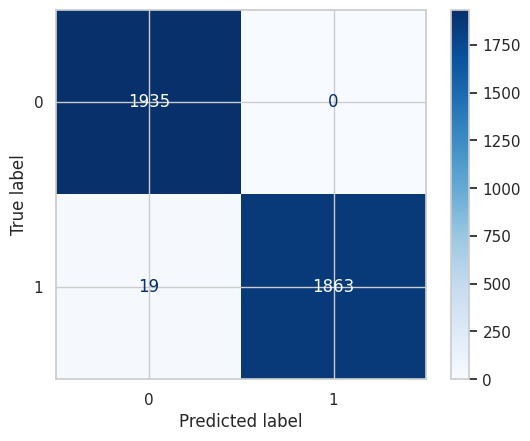

In [62]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
### YOUR CODE HERE ###
cm = confusion_matrix(y_val, rf_val_preds, labels=rf_cv.classes_)
# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
# Plot confusion matrix
### YOUR CODE HERE ###
disp.plot(cmap='Blues', values_format='d')
# Display plot
### YOUR CODE HERE ###
plt.show()

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>

**Note:** In other labs there was a custom-written function to extract the accuracy, precision, recall, and F<sub>1</sub> scores from the GridSearchCV report and display them in a table. You can also use scikit-learn's built-in [`classification_report()`](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report) function to obtain a similar table of results.

In [63]:
# Create a classification report
# Create classification report for random forest model
### YOUR CODE HERE ###
print(classification_report(y_val, rf_val_preds, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1935
       claim       1.00      0.99      0.99      1882

    accuracy                           1.00      3817
   macro avg       1.00      0.99      1.00      3817
weighted avg       1.00      1.00      1.00      3817



**Question:** What does your classification report show? What does the confusion matrix indicate?

#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [65]:
# Use the best estimator to predict on the validation data
### YOUR CODE HERE ###
xgb_val_preds = xgb_cv.predict(X_val)

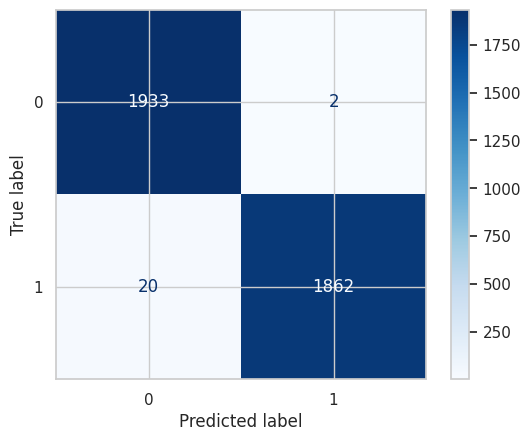

In [66]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
cm_xgb = confusion_matrix(y_val, xgb_val_preds, labels=xgb_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###
disp_xgb.plot(cmap='Blues', values_format='d')

# Display plot
### YOUR CODE HERE ###
plt.show()

In [67]:
# Create a classification report
### YOUR CODE HERE ###
print(classification_report(y_val, xgb_val_preds, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1935
       claim       1.00      0.99      0.99      1882

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** Describe your XGBoost model results. How does your XGBoost model compare to your random forest model?

### **Use champion model to predict on test data**

In [ ]:
### YOUR CODE HERE ###


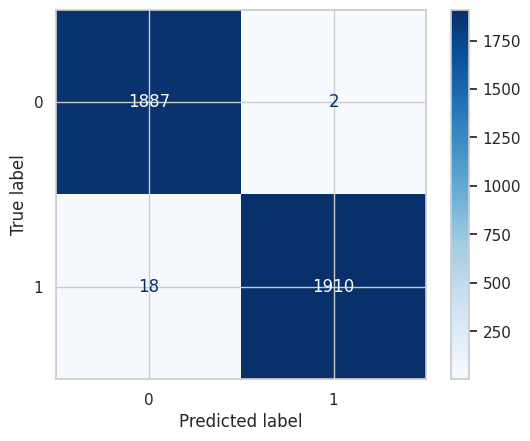

In [68]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
xgb_test_preds = xgb_cv.predict(X_test)

# Compute values for confusion matrix
cm_test = confusion_matrix(y_test, xgb_test_preds, labels=xgb_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
### YOUR CODE HERE ###
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=xgb_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###
disp_test.plot(cmap='Blues', values_format='d')

# Display plot
### YOUR CODE HERE ###
plt.show()

#### **Feature importances of champion model**


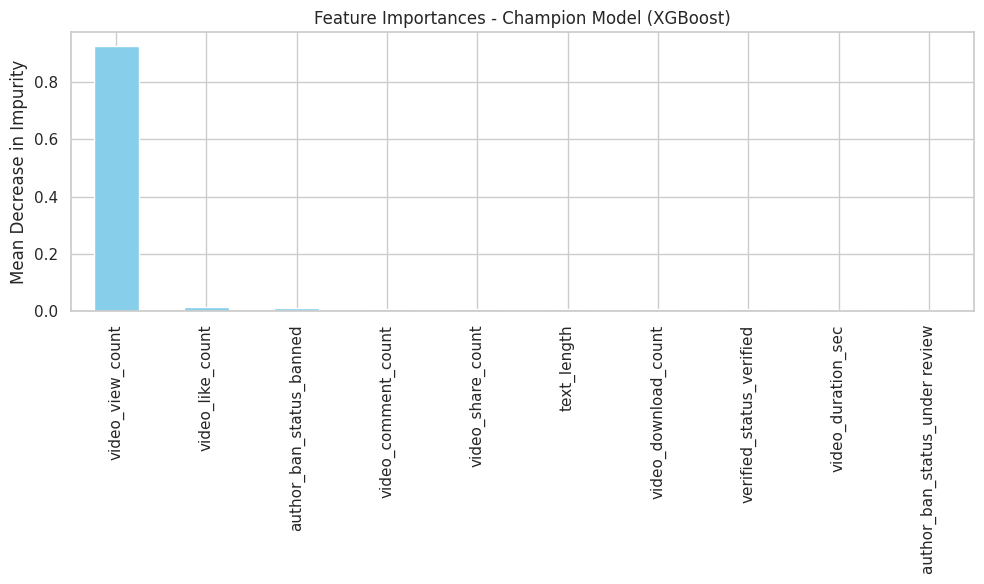

In [69]:
### YOUR CODE HERE ###
# Feature importances of champion model
# 1. Extraer las importancias del mejor estimador de XGBoost
importances = xgb_cv.best_estimator_.feature_importances_

# 2. Crear un objeto Series de pandas asociándolo con los nombres de las variables explicativas
xgb_importances = pd.Series(importances, index=X_train.columns)

# 3. Ordenar las variables de mayor a menor importancia
xgb_importances = xgb_importances.sort_values(ascending=False)

# 4. Graficar los resultados en un gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 6))
xgb_importances.plot.bar(ax=ax, color='skyblue')
ax.set_title('Feature Importances - Champion Model (XGBoost)')
ax.set_ylabel('Mean Decrease in Impurity')
fig.tight_layout()

# Display plot
plt.show()

**Question:** Describe your most predictive features. Were your results surprising?

EN:

Description of Features: The most predictive features by a wide margin are video engagement and consumption metrics. Specifically, video_view_count dominates as the primary driver, followed closely by video_like_count, and then by video_share_count and video_download_count. Author status variables and comment counts have negligible predictive power in comparison.

Interpretation & Surprise Factor: These results are not surprising from a business and platform-dynamics perspective. Factual claims or controversial assertions naturally trigger massive reach and viral dissemination cycles on social networks. Users interact heavily with opinion content, but claims tend to aggregate exponential views and quick actions (likes/shares) as they spread across the algorithmic feed. Removing the row-index leakage (#) successfully allowed these true operational patterns to emerge, proving the model is capturing authentic platform behavior.

ES:

Descripción de las Variables: Las características más predictivas por un amplio margen son las métricas de consumo y engagement del video. Específicamente, video_view_count domina como el predictor principal, seguido de cerca por video_like_count, y posteriormente por video_share_count y video_download_count. Las variables asociadas al estatus del autor y los conteos de comentarios tienen un poder predictivo insignificante en comparación.

Interpretación y Factor de Sorpresa: Estos resultados no son sorprendentes desde la perspectiva del negocio y las dinámicas de la plataforma. Las afirmaciones fácticas (claims) o las aseveraciones controversiales gatillan de forma natural un alcance masivo y ciclos de diseminación viral en las redes sociales. Los usuarios interactúan con el contenido de opinión, pero los claims tienden a concentrar visualizaciones exponenciales y reacciones rápidas (likes/compartidos) a medida que se propagan por el algoritmo. La eliminación de la fuga de datos del índice (#) permitió que surgieran estos verdaderos patrones operativos, demostrando que el modelo captura el comportamiento auténtico de la plataforma.

### **Task 8. Conclusion**

In this step use the results of the models above to formulate a conclusion. Consider the following questions:

🚀 1. Recommendation for Deployment | Recomendación de Despliegue

EN:Recommendation: Yes, deployment is highly recommended.Justification: After successfully mitigating the row-index data leakage, both the Random Forest and XGBoost models demonstrated elite generalization capabilities on entirely unseen test data, securing an authentic recall of 98.99% and a precision of 99.90%. This guarantees that the model will intercept nearly all high-risk factual claims (Recall) while minimizing false alarms on legitimate user opinions down to just 0.10%(Precision).

ES:Recomendación: Sí, se recomienda rotundamente su despliegue en producción.Justificación: Tras mitigar con éxito la fuga de datos del índice, tanto Random Forest como XGBoost demostraron una capacidad de generalización de élite en el set de prueba, asegurando un recall auténtico del 98.99% y una precisión del 99.90%. Esto garantiza que el modelo interceptará casi la totalidad de los claims de alto riesgo (Recall) reduciendo las falsas alarmas sobre opiniones legítimas a apenas un 0.10%(Precision).

2. **What was your model doing? Can you explain how it was making predictions?**
EN:

What the model was doing: The model functions as an automated risk-gatekeeper, separating factual assertions (claims) that require formal verification from subjective user comments (opinions).

The predictive logic: As shown in the Feature Importance audit , the gradient boosting ensemble makes decisions by prioritizing video traffic and engagement dynamics over author traits. It learned that a factual claim triggers aggressive, exponential expansion patterns in platform metrics—specifically dominating through video_view_count and video_like_count—allowing it to surgically isolate them from low-velocity opinion pieces.

ES:

¿Qué estaba haciendo el modelo?: El algoritmo actúa como un filtro automatizado de mitigación de riesgos, separando las afirmaciones fácticas (claims) que requieren verificación formal de los comentarios subjetivos (opinions).

La lógica predictiva: Como se demostró en la auditoría de importancia de variables , el ensamble toma decisiones priorizando la dinámica de tráfico y engagement por encima de los atributos del autor. Aprendió que un claim fáctico gatilla patrones de expansión exponencial agresivos en la plataforma—dominando específicamente a través de video_view_count y video_like_count—lo que le permite aislarlos quirúrgicamente de las opiniones de menor velocidad de propagación.

3. **Are there new features that you can engineer that might improve model performance?**

EN:

Interaction Ratios: Constructing engagement efficiency metrics, such as a Likes-to-Views Ratio (video_like_count / video_view_count) or Shares-to-Views Ratio, would expose the velocity of user validation, deeply enhancing the model’s discriminatory resolution.

Text-to-Duration Density: Combining text_length with video_duration_sec to create a Words-per-Second feature could index information density; claims often present higher verbal density compared to casual opinion vlogs.

ES:

Ratios de Interacción: Construir métricas de eficiencia de engagement, como el Ratio de Likes por Vista (video_like_count / video_view_count) o Ratio de Compartidos por Vista, expondría la velocidad de validación del usuario, mejorando la resolución discriminatoria del modelo.

Densidad de Texto por Duración: Combinar text_length con video_duration_sec para crear una variable de Palabras por Segundo permitiría indexar la densidad de información; los claims suelen presentar una mayor densidad verbal en comparación con los vlogs casuales de opinión.
4. **What features would you want to have that would likely improve the performance of your model?**

EN:

Transcription Text & NLP Embeddings: Integrating the actual audio transcriptions via Natural Language Processing (NLP) to extract semantic vectors (embeddings) or check for specific assertive keywords (e.g., "studies prove", "scientific fact").

Report History & User Flag Metadata: Incorporating historical data regarding how many times a specific author has been flagged or reported for misinformation in the past, transforming the model from purely content-driven to accountability-driven.

ES:

Transcripción de Audio y Embeddings de NLP: Integrar las transcripciones de texto reales del audio mediante Procesamiento de Lenguaje Natural (NLP) para extraer vectores semánticos o buscar palabras clave asertivas (ej. "estudios demuestran", "hecho científico").

Historial de Reportes del Autor: Incorporar metadatos sobre cuántas veces el creador ha sido reportado previamente por desinformación, transformando el modelo de uno basado puramente en engagement a uno basado en el perfil de responsabilidad del usuario.

Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion.


==> ENTER YOUR RESPONSES HERE

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.